In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
df=pd.read_csv("height-weight.csv")

In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0.5, 1.0, 'Scatter Plot b/w Height and Weight')

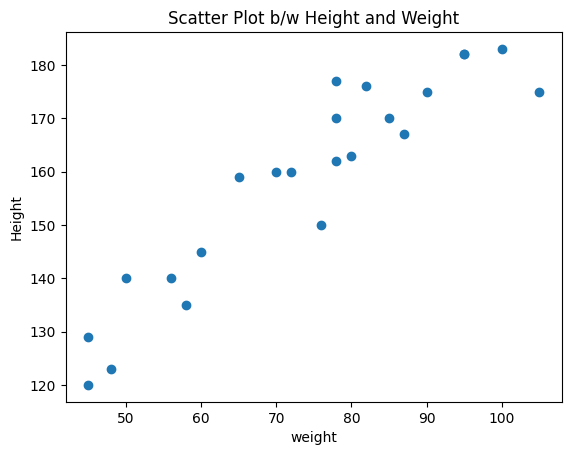

In [6]:
# Scatter plot
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("weight")
plt.ylabel("Height")
plt.title("Scatter Plot b/w Height and Weight")

In [7]:
# Correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


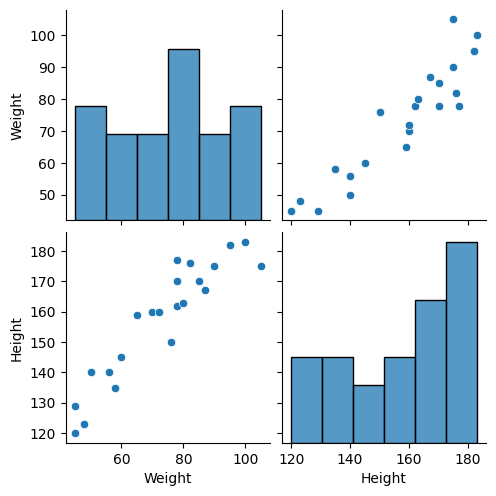

In [8]:
import seaborn as sns
sns.pairplot(df)

In [15]:
# Independent and Dependent Features
X=df[['Weight']] ## independent features should be dataframe or a 2-D array
y=df['Height'] ## only one dependent feature or Target variable,
## thus in series or 1-D array

In [16]:
X_series=df['Weight']
np.array(X_series).shape

(23,)

In [18]:
np.array(y).shape

(23,)

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [ ]:
## Standardization happens in SLR using Z-score, applied only to indpdt. feature
from sklearn.preprocessing import StandardScaler

In [ ]:
## Fit_transform applied on train data, to calculate mue,var.
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)

In [30]:
## Transform applies mue,var from tain data to test data --> Data Leakage
X_test=scaler.transform(X_test)

In [31]:
# Apply Simple Linear Regression
from sklearn.linear_model import LinearRegression

In [34]:
reg=LinearRegression(n_jobs=-1)

In [36]:
reg.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [38]:
print("Coefficient:",reg.coef_)
print("Intercept:",reg.intercept_)

Coefficient: [17.2982057]
Intercept: 156.47058823529412


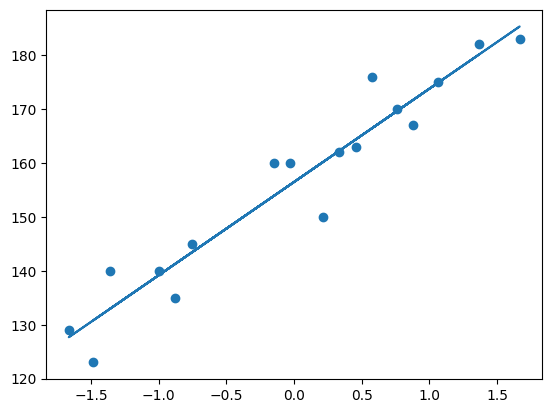

In [41]:
plt.scatter(X_train,y_train)
plt.plot(X_train,reg.predict(X_train))

### Prediction of test data
y_pred_test=156.47 + 17.29(X_test)

In [42]:
y_pred=reg.predict(X_test)

In [43]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [44]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.66512588679501
10.716374991212605


### R Square formula
R^2=1-SSR/SST

In [45]:
from sklearn.metrics import r2_score

In [47]:
score=r2_score(y_test,y_pred)
print(score)

0.7360826717981276


### Adjusted R^2 formula
Adjusted R^2 = 1 — [(1-R^2)*(n-1)/(n-k-1)]

In [48]:
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.6701033397476595

In [50]:
import statsmodels.api as sm

In [51]:
model=sm.OLS(y_train,X_train).fit()

In [53]:
new_predict=model.predict(X_test)
print(new_predict)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [54]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Fri, 03 Oct 2025   Prob (F-statistic):                       0.664
Time:                        19:22:08   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

e:\ML Bootcamp Krish Naik\Code\venv\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [55]:
## Prediction for new data
reg.predict(scaler.transform([[72]]))

e:\ML Bootcamp Krish Naik\Code\venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])